# McStas Workflow
In this example, we will use McStas 3 simulation file.

## Build Pipeline (Collect Parameters and Providers)
Import the providers from ``load_mcstas_nexus`` to use the ``McStas`` simulation data workflow. <br>
``MaximumProbability`` can be manually provided to derive more realistic number of events. <br>
It is because ``weights`` are given as probability, not number of events in a McStas file. <br>

In [1]:
from ess.nmx.mcstas import NMXMcStasWorkflow
from ess.nmx.data import get_small_mcstas

from ess.nmx.mcstas.types import *
from ess.nmx.mcstas.reduction import merge_panels
from ess.nmx.mcstas.nexus import export_as_nexus

wf = NMXMcStasWorkflow()
# Replace with the path to your own file
wf[FilePath] = get_small_mcstas()
wf[MaximumCounts] = 10000
wf[TimeBinSteps] = 50

To see what the workflow can produce, display it:

In [2]:
wf

We want to reduce all three panels, so we map the relevant part of the workflow over a list of the three panels:

In [3]:
# DetectorIndex selects what detector panels to include in the run
# in this case we select all three panels.
wf[NMXReducedDataGroup] = (
    wf[NMXReducedDataGroup]
    .map({DetectorIndex: sc.arange('panel', 3, unit=None)})
    .reduce(index="panel", func=merge_panels)
)

## Build Workflow

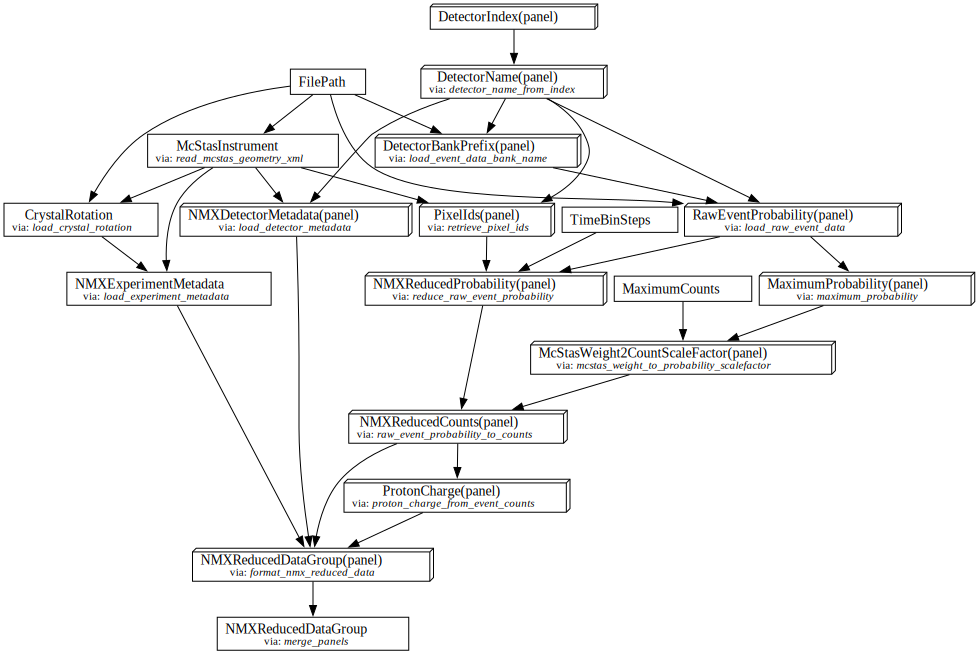

In [4]:
wf.visualize(NMXReducedDataGroup, graph_attr={"rankdir": "TD"}, compact=True)

## Compute Desired Types

In [5]:
from cyclebane.graph import NodeName, IndexValues

# Data from all selected detectors binned by panel, pixel and timeslice
targets = [NodeName(NMXReducedDataGroup, IndexValues(("panel",), (i,))) for i in range(3)]
dg = merge_panels(*wf.compute(targets).values())
dg

DataGroup(sizes={'panel': 3, 'id': 1638400, 't': 50}, keys=[
    counts: DataArray({'panel': 3, 'id': 1638400, 't': 50}),
    proton_charge: Variable({'panel': 3}),
    crystal_rotation: Variable({}),
    sample_position: Variable({}),
    source_position: Variable({}),
    sample_name: Variable({}),
    fast_axis: Variable({'panel': 3}),
    slow_axis: Variable({}),
    origin_position: Variable({'panel': 3}),
    position: Variable({'panel': 3, 'id': 1638400}),
    detector_shape: Variable({}),
    x_pixel_size: Variable({}),
    y_pixel_size: Variable({}),
    detector_name: Variable({'panel': 3}),
])

In [6]:
dg['counts']

<scipp.DataArray>
Dimensions: Sizes[panel:3, id:1638400, t:50, ]
Coordinates:
* id                          int64        <no unit>  (panel, id)  [1, 2, ..., 5638398, 5638399]
* t                         float64              [s]  (panel, t [bin-edge])  [0.0972552, 0.0981673, ..., 0.144357, 0.145276]
Data:
                            float64         [counts]  (panel, id, t)  [0, 0, ..., 0, 0]

## Export Results

``NMXReducedData`` object has a method to export the data into nexus or h5 file.

You can save the result as ``test.nxs``, for example:


In [7]:
export_as_nexus(dg, "test.nxs")

/tmp/ipykernel_8294/608274272.py:1: DeprecationWarning: Exporting to custom NeXus format will be deprecated in the near future >=26.12.0. Please use ``export_as_nxlauetof`` instead.
  export_as_nexus(dg, "test.nxs")


## Instrument View

Pixel positions are not used for later steps,
but it is included in the coordinates for instrument view.

All pixel positions are relative to the sample position,
therefore the sample is at (0, 0, 0).

**It might be very slow or not work in the ``VS Code`` jupyter notebook editor.**

In [8]:
import scippneutron as scn

da = dg["counts"]
da.coords["position"] = dg["position"]
# Plot one out of 100 pixels to reduce size of docs output
view = scn.instrument_view(da["id", ::100].sum('t'), pixel_size=0.0075)
view

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…